## 1. Install paket

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/xpu -q
%pip install intel-extension-for-pytorch -q
%pip install timm scikit-learn grad-cam seaborn opencv-python tqdm -q


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement intel-extension-for-pytorch (from versions: none)
ERROR: No matching distribution found for intel-extension-for-pytorch


Note: you may need to restart the kernel to use updated packages.


## 2. Imports & Config

In [2]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm

# Intel Extension for PyTorch (IPEX) — aktifkan jika tersedia
try:
    import intel_extension_for_pytorch as ipex
    IPEX_AVAILABLE = True
except ImportError:
    IPEX_AVAILABLE = False

# ── Config
SEED        = 42
DATA_DIR    = "dataset-soto-v2"
NUM_CLASSES = 6
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 3e-4
# Deteksi device: Intel Arc (xpu) → CUDA → CPU
if torch.xpu.is_available():
    DEVICE = torch.device("xpu")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"Device      : {DEVICE}")
if DEVICE.type == "xpu":
    print(f"Intel GPU   : {torch.xpu.get_device_name(0)}")
    print(f"IPEX        : {'enabled' if IPEX_AVAILABLE else 'not found — install intel-extension-for-pytorch'}")
elif DEVICE.type == "cuda":
    print(f"CUDA GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("  ⚠ Tidak ada GPU terdeteksi, berjalan di CPU")


c:\Users\degap\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device      : xpu
Intel GPU   : Intel(R) Arc(TM) A530M Graphics
IPEX        : not found — install intel-extension-for-pytorch


## 3. Transforms

In [3]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

## 4. Dataset Info

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"))
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"))
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"))
full_dataset = train_dataset

print(f"  Train  : {len(train_dataset):>6} images")
print(f"  Val    : {len(val_dataset):>6} images")
print(f"  Test   : {len(test_dataset):>6} images")
print(f"\n  Kelas: {train_dataset.classes}")
print(f"\n  Per-class breakdown:")
import numpy as np
for i, cls in enumerate(train_dataset.classes):
    tr = sum(1 for _, l in train_dataset.imgs if l == i)
    v  = sum(1 for _, l in val_dataset.imgs   if l == i)
    te = sum(1 for _, l in test_dataset.imgs  if l == i)
    print(f"  {cls:<25} train={tr:>4}  val={v:>3}  test={te:>3}")


  Train  :   3246 images
  Val    :    693 images
  Test   :    693 images

  Kelas: ['coto_makassar', 'soto_bandung', 'soto_betawi', 'soto_lamongan', 'soto_medan', 'soto_padang']

  Per-class breakdown:
  coto_makassar             train= 491  val=105  test=105
  soto_bandung              train= 445  val= 95  test= 95
  soto_betawi               train= 677  val=144  test=144
  soto_lamongan             train= 748  val=160  test=160
  soto_medan                train= 352  val= 75  test= 75
  soto_padang               train= 533  val=114  test=114


## 5. DataLoaders

In [5]:
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


Train batches : 102
Val   batches : 22
Test  batches : 22


## 6. Model DeiT tiny

In [6]:
model = create_model("deit_tiny_patch16_224", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

if DEVICE.type == "xpu" and IPEX_AVAILABLE:
    model, optimizer_tmp = ipex.optimize(model, optimizer=None, dtype=torch.float32)
    print("IPEX optimization applied ✓")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params    : 5,525,574
Trainable params: 5,525,574


## 7. Loss, Optimizer & Scheduler

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# Re-optimize bersama optimizer jika pakai Intel Arc (overwrite optimize dari Cell 6)
if DEVICE.type == "xpu" and IPEX_AVAILABLE:
    model, optimizer = ipex.optimize(model, optimizer=optimizer, dtype=torch.float32)
    print("IPEX optimization with optimizer applied ✓")


## 8. Training

In [8]:
import time
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_epoch = 0, 0

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            
            if train: 
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            
            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc; best_epoch = epoch
        torch.save(model.state_dict(), "Model/Deit_Tiny_ARC.pth")
 
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f"Epoch: {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2%} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.2%} | Time: {int(epoch_mins)}m {int(epoch_secs):02d}s")

print(f"Best Val Acc: {best_val_acc:.2%} at epoch {best_epoch}")

Epoch: 1/20 | Train Loss: 1.4142 | Train Acc: 49.57% | Val Loss: 0.9944 | Val Acc: 72.29% | Time: 0m 44s
Epoch: 2/20 | Train Loss: 0.9456 | Train Acc: 75.14% | Val Loss: 0.8523 | Val Acc: 78.07% | Time: 0m 27s
Epoch: 3/20 | Train Loss: 0.7947 | Train Acc: 82.29% | Val Loss: 0.8232 | Val Acc: 81.82% | Time: 0m 30s
Epoch: 4/20 | Train Loss: 0.7335 | Train Acc: 85.58% | Val Loss: 0.7665 | Val Acc: 82.97% | Time: 0m 27s
Epoch: 5/20 | Train Loss: 0.6787 | Train Acc: 88.20% | Val Loss: 0.8260 | Val Acc: 80.09% | Time: 0m 34s
Epoch: 6/20 | Train Loss: 0.6130 | Train Acc: 91.00% | Val Loss: 0.8116 | Val Acc: 82.25% | Time: 0m 31s
Epoch: 7/20 | Train Loss: 0.5965 | Train Acc: 92.24% | Val Loss: 0.7485 | Val Acc: 85.14% | Time: 0m 31s
Epoch: 8/20 | Train Loss: 0.5499 | Train Acc: 94.45% | Val Loss: 0.7188 | Val Acc: 86.29% | Time: 0m 35s
Epoch: 9/20 | Train Loss: 0.5443 | Train Acc: 94.67% | Val Loss: 0.7081 | Val Acc: 86.29% | Time: 0m 34s
Epoch: 10/20 | Train Loss: 0.5134 | Train Acc: 95.84% |

## 9. Training Curve

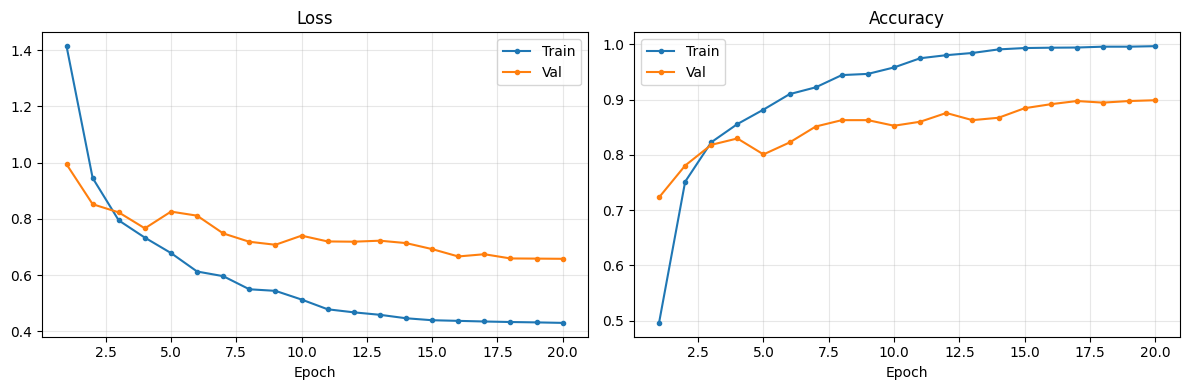

In [9]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history["train_loss"], label="Train", marker="o", ms=3)
ax1.plot(epochs_range, history["val_loss"],   label="Val",   marker="o", ms=3)
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history["train_acc"],  label="Train", marker="o", ms=3)
ax2.plot(epochs_range, history["val_acc"],    label="Val",   marker="o", ms=3)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Dokumentasi/training_curve_ARC.png", dpi=120)
plt.show()

## 10. Evaluation data test 

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("Model/Deit_Tiny_ARC.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

               precision    recall  f1-score   support

coto_makassar       0.92      0.91      0.92       105
 soto_bandung       0.93      0.87      0.90        95
  soto_betawi       0.88      0.93      0.91       144
soto_lamongan       0.88      0.91      0.90       160
   soto_medan       0.85      0.75      0.79        75
  soto_padang       0.90      0.91      0.90       114

     accuracy                           0.89       693
    macro avg       0.89      0.88      0.89       693
 weighted avg       0.89      0.89      0.89       693



## 11. Confusion Matrix

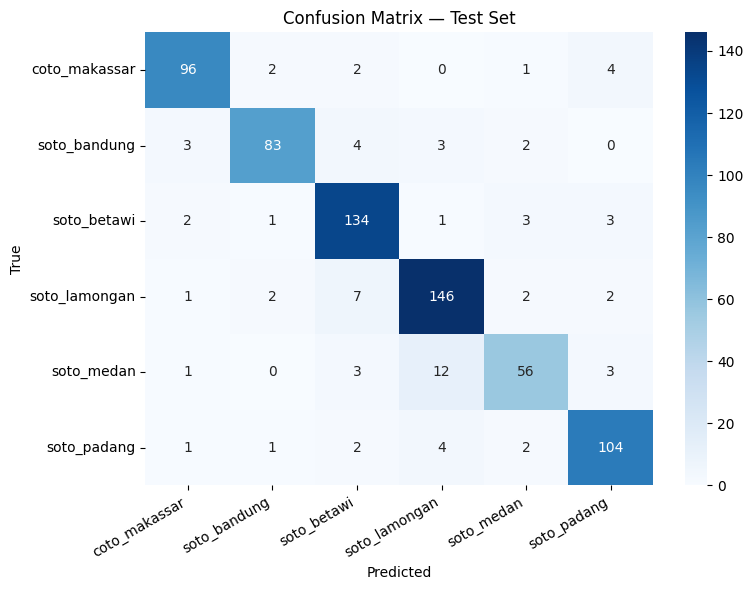

In [11]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("Dokumentasi/confusion_matrix_ARC.png", dpi=120)
plt.show()